# This noteboook aims to do an initial analysis of ERA5 and ERA5land Tmax data for identifying heatwave events over europe 

In [1]:
# ------------------------------------- Used libraries --------------------------------------------
import numpy as np
from matplotlib import pyplot as plt
from netCDF4 import Dataset as ncread
import xarray as xr 
from scipy.stats import linregress
from datetime import datetime, timedelta
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import os
import re
import ast
import xesmf as xe#for regridding 
from matplotlib.backends.backend_pdf import PdfPages
import preprocess_for_NN


## ERA5 land

Get the data from esarchive. There is one nc file for each month, and contains daily data of Tmax

### Open saved dataset

### Detrended Data

### Define fucntions 

Functions for computation of cliamtology and percentiles are in file functions_HW.py

Percentile definition taken from Peskins & Alexander: On the measurement of Heat Waves: https://journals.ametsoc.org/view/journals/clim/26/13/jcli-d-12-00383.1.xml

LOESS fit is passed to the percentile values based on Mahlstein et al. 2015

# Anomalies

Code to save the anomalies for each sat in a netCDF file. Anomalies are standarized using:

$$standarized_{anomaly} = \frac{anomaly-\mu}{\sigma}$$

These anomalies will serve as input for the ANN

In [5]:
import functions_HW

sites = ['cordoba','hannover','stockholm','lyon','belgrado','marrakech']
outputpath = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/anomalies/"


variables = ['tasmax','tasmin','swvl1','swvl2','swvl3']

for site in sites: 

    path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/variables_era5land_data_{site}_1950_2024.nc'
    ds = xr.open_dataset(path) #open dataset

    for variable in variables: 
    
        #extract anomalies with climatology computed using loess fitting. Select reference period for the climatology computation 
        standarized_anomalies = functions_HW.Compute_anomalies(ds,variable,'1950','2000') #call Compute_anomalies function

        #Save the two type anomalies for the variable
        ds[f'{variable}_anomalies'] = standarized_anomalies
        ds[f'{variable}_anomalies'].attrs = {
            'long_name':'Anomalies with loess climatology',
            'description':'These anomalies have been computed with a loess fit on a raw computation of the climatology'
        }
     
    #Save new netCDF file including the anomalies computed with the two methods 
    ds.to_netcdf(outputpath+f"std_changed_variables_era5land_data_with_anomalies_{site}_1950_2024.nc")

    
    

# Trends in the variables

### netCDF files data without trend 

# Detect Heatwaves events for data with trend 

Time variable configuration for the reference period and the whole period

Computation of 90th percentile and Heatwave events detection 

HW events can be detected either for ERA5 or ERA5 land data 

Some metrics for the Heatwaves analysis:

* Duration: number of consecutive days that the selected percentile is exceeded in a region or grid-point
* Frequency: counting of number of heatwaves in a region or grid-point
* Maximum intensity: maximum intensity value for a Heatwave event in a certain region or grid-point
* Mean intensity: averaged intensity of a Heatwave event
* Accumulated intensity: integrated intensity over time for a given Heatwave event in a certain region or grid-point

In [5]:
import functions_HW
import loess_functions

sites = ['cordoba', 'hannover', 'stockholm', 'lyon', 'belgrado', 'marrakech']
#variables = ['swvl1','swvl2','swvl3']
variables = ['spei_hg_3']

variable_extreme = 'tasmax'

#This loop wil create a csv file of dates and duration of detected extreme events for the full period contained in the netCDF file. 
#Additionally, it creates a .txt file with metrics for the extreme events in the diferent locations defined in sites. 

for site in sites:

    path =  f'/gpfs/projects/bsc32/bsc167965/observational_TX/spei_tasmax_{site}_hg_3.nc'
    #path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/variables_era5land_data_{site}_1950_2024.nc'
    ds = xr.open_dataset(path).sel(time=slice('1950','2023'))

    # climatology, percentile, and window
    #the climatology is computed for the reference period only, and same for the percentile 
    climatology,percentile,clim_window,full_window,loess_clim = functions_HW.Compute_window_percentile_reference_period(ds,'tasmax',0.9,5,'1950','2000')

    #remove 29th of febraury and original variables--------------------------------------------------------------------------
    if 366 in percentile.dayofyear:
        ds = ds.sel(time=~((ds.time.dt.month == 2) & (ds.time.dt.day == 29)))
    
    #apply loess fit to the raw_percentile 
    loess_percentile = loess_functions.loess_ts(percentile, na_rm=True,  window=30,  degree=1)
    
    #convert the loess_percentile data into xarray to use it as input in detect_HW() funtion
    
    # Create a new xarray.DataArray with the same format as percentile
    loess_percentile_xarray = xr.DataArray(
        loess_percentile, 
        dims=["dayofyear"], 
        coords={"dayofyear": percentile.dayofyear},  # Use the same dayofyear coordinate
        name="loess_percentile"
    )

    #Call detect heatwave function for the max temperature data, either ERA5 or ERA5 land 
    # DateTime_time_out_detect: datetime used in detect_HW_functions. Will be used in Compute_metrics function to get the frequencies of individual periods of time 
    HW_mask,HW_intensity,DateTime_time_out_detect = functions_HW.detect_HW(ds,variable_extreme,loess_percentile_xarray,3,site) 
    #HW_mask will give a number of True values around 10% if the 90th percentile is used 

   # Call the anomalies function to create netcdf files that have the standarized anomalies and 0s and 1s for th extreme event classification -------------------------------

    output_path = '/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/obs_anomalies_and_evet_detection/'
    file_path = f'spei3_{site}_standarized_anomalies_and_extreme_detection.nc'

    ds_save = ds.copy()
    
    HW_mask_0_1 = HW_mask.astype(int) #convert boolean mask to 0s and 1s 


    #Compute the anomalies for all the ERA5 land data and save in the ds file ------------------------------------------------------
    for var in variables:
        anomalies = functions_HW.Compute_anomalies(ds,var,'1950','2000')   

        #Save the two type anomalies for the variable
        ds_save[f'{var}_anomalies'] = xr.DataArray(
            anomalies.values,
            coords={'time': ds.time},
            dims=['time']
        )
        ds_save[f'{var}_anomalies'].attrs = {
            'long_name':f'{var} standarized anomalies with loess fit climatology',
            'description':f'These anomalies for ERAland {var} have been computed with a raw computation of the climatology to which a loess fitting is applied afterwards'
        }

    #Drop the original variables, just saving the anomlies and the extreme non-extreme classification
    #ds_save = ds_save.drop_vars(variables)

    # -------------------------------------------------------------------------------------------------

    #Save the extreme classification
    ds_save[f'{variable_extreme}_extreme_classification'] = (('time'),HW_mask_0_1)
    ds_save[f'{variable_extreme}_extreme_classification'].attrs = {
        'extreme detection with percentile 90 and detrended data':'Anomalies with 5-day window fit climatology',
        'description': ("1 stands for extreme event in that time and space point, 0 stands for non-extreme. Detection was done usnig a smoothed loess fit percentile and a moving 5-day window climatology. Both percentile and climatology are computed only for the reference period 1971-2000." )
    }

    ds_save.to_netcdf(output_path+file_path)

    # ------------------------------------------------------------------------------------------------------------------

    #Move to metric computation using Compute_metrics funtion 
    

    #Call function to compute metrics of the detected extreme events 
    duration,frequency,frequencies_selected_periods,max_intensity,mean_intensity,cumulative_intensity,period_percentages,period_counts = functions_HW.Compute_metrics(HW_mask,HW_intensity,DateTime_time_out_detect)

    #Write in a pdf file the metrics of the extreme events detected 
    
    with open(f'HW_dates_detected_and_metrics/spei3_heatwave_stats_{site}.txt', 'w') as file:
        # Write each statistic to the file
        file.write(f'Site:{site} \n')
        file.write(f'Time period: 1950-2024 \n')
        file.write(f'Reference time period for 90th percentile computation: 1971-2000 \n')
        file.write(f'Minimum duration for heat wave event: 3 days \n')    
        file.write(f'Max duration of event: {duration.max()}\n')
        file.write(f'Min duration of event: {duration.min()}\n')
        file.write(f'Frequency in the grid-point: {frequency}\n')
        file.write(f'Frequency in the grid-point for the selected periods: {frequencies_selected_periods}\n')
        file.write(f'Count normal and extreme days per period: {period_counts}\n')
        file.write(f'Percentages normal and extreme days per period: {period_percentages}\n')
        file.write(f"Max value of max intensity: {max_intensity.max()}\n")
        file.write(f'Mean intensity: {mean_intensity.max()}\n')
        file.write(f'Max accumulated intensity: {cumulative_intensity.max()}\n')
        file.write(f'Min accumulated intensity: {cumulative_intensity.min()}\n')
        
    

Heatwave events saved to 'heatwave_events_1950_2024_cordoba.csv'
All days 1950-2000 = 18615
{'1950-2000': {'HW_days': np.int64(1897), 'All_days': np.int64(18615)}, '1971-2000': {'HW_days': np.int64(1293), 'All_days': np.int64(10950)}, '2001-2024': {'HW_days': np.int64(1589), 'All_days': np.int64(8395)}}
{'1950-2000': {'HW_days_percent': np.float64(10.190706419554123)}, '1971-2000': {'HW_days_percent': np.float64(11.808219178082192)}, '2001-2024': {'HW_days_percent': np.float64(18.92793329362716)}}
{'1950-2000': 732, '1971-2000': 486, '2001-2024': 534}
Heatwave events saved to 'heatwave_events_1950_2024_hannover.csv'
All days 1950-2000 = 18615
{'1950-2000': {'HW_days': np.int64(1899), 'All_days': np.int64(18615)}, '1971-2000': {'HW_days': np.int64(1218), 'All_days': np.int64(10950)}, '2001-2024': {'HW_days': np.int64(1449), 'All_days': np.int64(8395)}}
{'1950-2000': {'HW_days_percent': np.float64(10.201450443190975)}, '1971-2000': {'HW_days_percent': np.float64(11.123287671232877)}, '20

IndexError: index 22 is out of bounds for axis 0 with size 22

## Observational data for TX

In [53]:
import functions_HW
import loess_functions

sites = ['cordoba', 'hannover', 'stockholm', 'lyon', 'belgrado', 'marrakech']
variables = ['swvl1','swvl2','swvl3']

variable_extreme = 'tasmax'

#This loop wil create a csv file of dates and duration of detected extreme events for the full period contained in the netCDF file. 
#Additionally, it creates a .txt file with metrics for the extreme events in the diferent locations defined in sites. 

for site in sites:

    path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/variables_era5land_data_{site}_1950_2024.nc'
    ds_swvl = xr.open_dataset(path).sel(time=slice('1950','2023'))
    path = f"/gpfs/projects/bsc32/bsc167965/observational_TX/observational_TX_data_{site}_1950_2024.nc"
    ds_tx = xr.open_dataset(path)

    # climatology, percentile, and window
    #the climatology is computed for the reference period only, and same for the percentile 
    climatology,percentile,clim_window,full_window,loess_clim = functions_HW.Compute_window_percentile_reference_period(ds_tx,'tasmax',0.9,5,'1950','2000')

    #remove 29th of febraury and original variables--------------------------------------------------------------------------
    if 366 in percentile.dayofyear:
        ds_swvl = ds_swvl.sel(time=~((ds_swvl.time.dt.month == 2) & (ds_swvl.time.dt.day == 29)))
        ds_tx = ds_tx.sel(time=~((ds_tx.time.dt.month == 2) & (ds_tx.time.dt.day == 29)))
    
    #apply loess fit to the raw_percentile 
    loess_percentile = loess_functions.loess_ts(percentile, na_rm=True,  window=30,  degree=1)
    
    #convert the loess_percentile data into xarray to use it as input in detect_HW() funtion
    
    # Create a new xarray.DataArray with the same format as percentile
    loess_percentile_xarray = xr.DataArray(
        loess_percentile, 
        dims=["dayofyear"], 
        coords={"dayofyear": percentile.dayofyear},  # Use the same dayofyear coordinate
        name="loess_percentile"
    )

    #Call detect heatwave function for the max temperature data, either ERA5 or ERA5 land 
    # DateTime_time_out_detect: datetime used in detect_HW_functions. Will be used in Compute_metrics function to get the frequencies of individual periods of time 
    HW_mask,HW_intensity,DateTime_time_out_detect = functions_HW.detect_HW(ds_tx,variable_extreme,loess_percentile_xarray,3,site) 
    #HW_mask will give a number of True values around 10% if the 90th percentile is used 

   # Call the anomalies function to create netcdf files that have the standarized anomalies and 0s and 1s for th extreme event classification -------------------------------

    output_path = '/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/obs_anomalies_and_evet_detection/'
    file_path = f'obs_{site}_standarized_anomalies_and_extreme_detection.nc'

    ds_save = ds_tx.copy()
    
    HW_mask_0_1 = HW_mask.astype(int) #convert boolean mask to 0s and 1s 


    #Compute the anomalies for all the ERA5 land data and save in the ds file ------------------------------------------------------
    for var in variables:
        anomalies = functions_HW.Compute_anomalies(ds_swvl,var,'1950','2000')   

        #Save the two type anomalies for the variable
        ds_save[f'{var}_anomalies'] = xr.DataArray(
            anomalies.values,
            coords={'time': ds_tx.time},
            dims=['time']
        )
        ds_save[f'{var}_anomalies'].attrs = {
            'long_name':f'{var} standarized anomalies with loess fit climatology',
            'description':f'These anomalies for ERAland {var} have been computed with a raw computation of the climatology to which a loess fitting is applied afterwards'
        }

    #Drop the original variables, just saving the anomlies and the extreme non-extreme classification
    #ds_save = ds_save.drop_vars(variables)

    # -------------------------------------------------------------------------------------------------

    #Save the extreme classification
    ds_save[f'{variable_extreme}_extreme_classification'] = (('time'),HW_mask_0_1)
    ds_save[f'{variable_extreme}_extreme_classification'].attrs = {
        'extreme detection with percentile 90':'Anomalies with 5-day window fit climatology',
        'description': ("1 stands for extreme event in that time and space point, 0 stands for non-extreme. Detection was done usnig a smoothed loess fit percentile and a moving 5-day window climatology. Both percentile and climatology are computed only for the reference period 1971-2000." )
    }

    ds_save.to_netcdf(output_path+file_path)

    # ------------------------------------------------------------------------------------------------------------------

    #Move to metric computation using Compute_metrics funtion 
    

    #Call function to compute metrics of the detected extreme events 
    duration,frequency,frequencies_selected_periods,max_intensity,mean_intensity,cumulative_intensity,period_percentages,period_counts = functions_HW.Compute_metrics(HW_mask,HW_intensity,DateTime_time_out_detect)

    #Write in a pdf file the metrics of the extreme events detected 
    
    with open(f'HW_dates_detected_and_metrics/obs_heatwave_stats_{site}.txt', 'w') as file:
        # Write each statistic to the file
        file.write(f'Site:{site} \n')
        file.write(f'Time period: 1950-2024 \n')
        file.write(f'Reference time period for 90th percentile computation: 1971-2000 \n')
        file.write(f'Minimum duration for heat wave event: 3 days \n')    
        file.write(f'Max duration of event: {duration.max()}\n')
        file.write(f'Min duration of event: {duration.min()}\n')
        file.write(f'Frequency in the grid-point: {frequency}\n')
        file.write(f'Frequency in the grid-point for the selected periods: {frequencies_selected_periods}\n')
        file.write(f'Count normal and extreme days per period: {period_counts}\n')
        file.write(f'Percentages normal and extreme days per period: {period_percentages}\n')
        file.write(f"Max value of max intensity: {max_intensity.max()}\n")
        file.write(f'Mean intensity: {mean_intensity.max()}\n')
        file.write(f'Max accumulated intensity: {cumulative_intensity.max()}\n')
        file.write(f'Min accumulated intensity: {cumulative_intensity.min()}\n')
        
    

Heatwave events saved to 'heatwave_events_1950_2024_cordoba.csv'
All days 1950-2000 = 18615
{'1950-2000': {'HW_days': np.int64(1897), 'All_days': np.int64(18615)}, '1971-2000': {'HW_days': np.int64(1293), 'All_days': np.int64(10950)}, '2001-2024': {'HW_days': np.int64(1589), 'All_days': np.int64(8395)}}
{'1950-2000': {'HW_days_percent': np.float64(10.190706419554123)}, '1971-2000': {'HW_days_percent': np.float64(11.808219178082192)}, '2001-2024': {'HW_days_percent': np.float64(18.92793329362716)}}
{'1950-2000': 732, '1971-2000': 486, '2001-2024': 534}
Heatwave events saved to 'heatwave_events_1950_2024_hannover.csv'
All days 1950-2000 = 18615
{'1950-2000': {'HW_days': np.int64(1899), 'All_days': np.int64(18615)}, '1971-2000': {'HW_days': np.int64(1218), 'All_days': np.int64(10950)}, '2001-2024': {'HW_days': np.int64(1449), 'All_days': np.int64(8395)}}
{'1950-2000': {'HW_days_percent': np.float64(10.201450443190975)}, '1971-2000': {'HW_days_percent': np.float64(11.123287671232877)}, '20

### Reproduce plot Mahlstein et al. : https://agupubs.onlinelibrary.wiley.com/doi/full/10.1002/2014JD022327

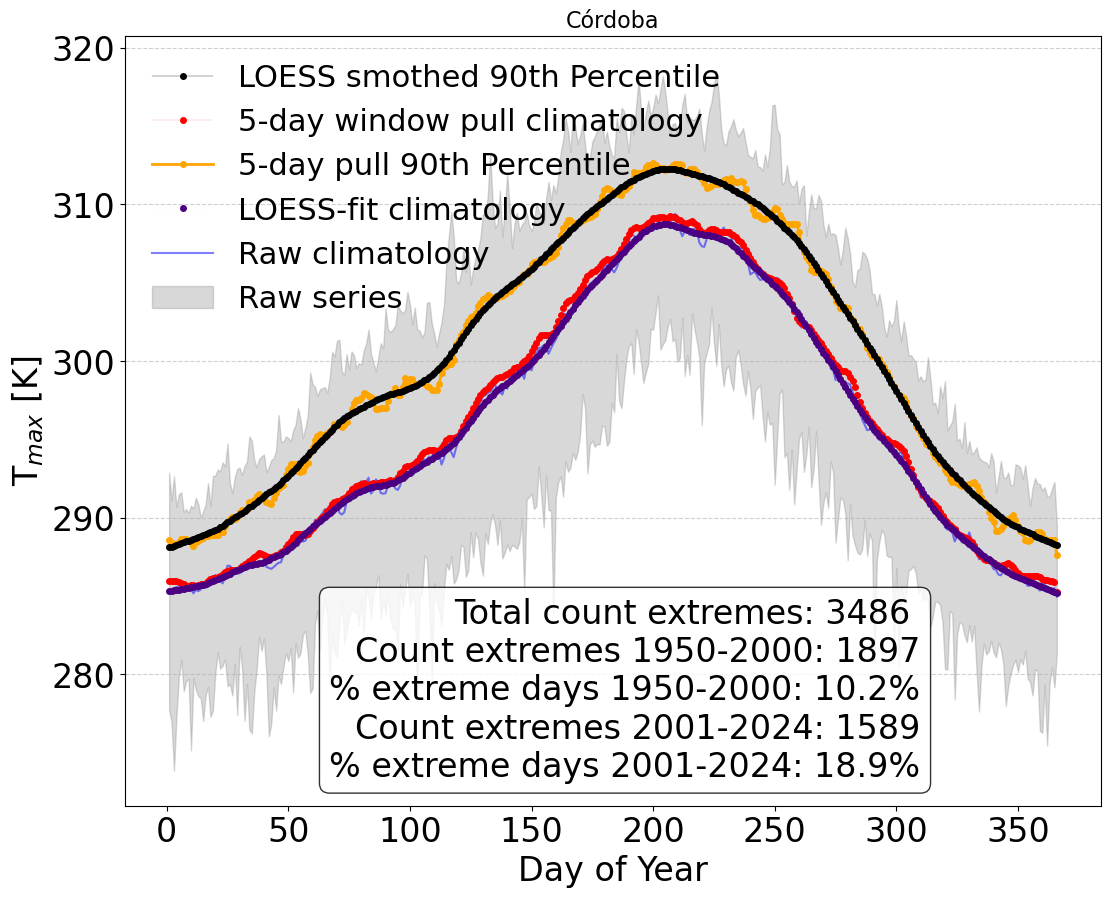

In [6]:
#import python script that contains fucntions for th eHW analysis 
import functions_HW
import loess_functions

sites = ['cordoba','hannover','stockholm','lyon','belgrado','marrakech']
sites_labels = ['Córdoba','Hannover','Stockholm','Lyon','Belgrado','Marrakech']
sites = ['cordoba']

#Defined studied variable 
variable = 'tasmax'

for site,site_label in zip(sites,sites_labels): 

    #path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/variables_era5land_data_{site}_1950_2024.nc'
    #ds_swvl = xr.open_dataset(path)  
    path =  f'/gpfs/projects/bsc32/bsc167965/observational_TX/spei_tasmax_{site}_hg_3.nc'
    ds = xr.open_dataset(path)

    # Ensure time is in datetime format
    ds['time'] = pd.to_datetime(ds['time'])

    # Compute daily min and max temperatures across all years
    daily_min = ds[variable].groupby("time.dayofyear").min("time")
    daily_max = ds[variable].groupby("time.dayofyear").max("time")
    # Get day-of-year for x-axis
    days = daily_min.dayofyear

    #extract climatology, window-climatology, percentile
    #Can be computed for a certain reference period or for the full available time period
    climatology,percentile,clim_window,window_series,loess_clim = functions_HW.Compute_window_percentile_reference_period(ds,variable,0.9,5,'1950','2000')

    #apply LOESS to percentile array
    percentile_LOESS = loess_functions.loess_ts(percentile, na_rm=True,  window=40,  degree=1)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12.6, 10))
    
    # Plot daily tasmax
    ax.plot(climatology['dayofyear'].values, climatology.values, color='blue', alpha=0.5, label='Raw climatology')
    
    # Overlay 90th percentile with same x-axis
    ax.plot(percentile['dayofyear'], percentile, color='orange', linewidth=2, marker='o', markersize=4, label='5-day pull 90th Percentile')
    ax.plot(percentile['dayofyear'], percentile_LOESS, color='black', linewidth=0.25, marker='o', markersize=4, label='LOESS smothed 90th Percentile')
    
    #n-window
    ax.plot(clim_window['dayofyear'], clim_window.values, color='red', linewidth=0.1, marker='o', markersize=4, label='5-day window pull climatology')

    #loess clim 
    ax.plot(loess_clim['dayofyear'], loess_clim.values, color='#4B0082', linewidth=0.01, marker='o', markersize=4, label='LOESS-fit climatology')

    #background with all the series 
    ax.fill_between(days, daily_min, daily_max, color="gray", alpha=0.3, label="Raw series")

    # Add text box with count of extreme events ------------------------------------- 

    file_path = f'HW_dates_detected_and_metrics/spei3_heatwave_stats_{site}.txt'
    with open(file_path, 'r') as file:
        content = file.read()

    # Extract values using regex
    freq_selected = re.search(r"Count normal and extreme days per period: (.*)", content).group(1)
    freq_selected = freq_selected.replace("np.int64", "")
    percentages = re.search(r"Percentages normal and extreme days per period: (.*)", content).group(1)
    percentages = re.sub(r"np\.float64\(([\d.eE+-]+)\)", r"\1", percentages)
    
    # Convert string dictionaries to actual Python dictionaries
    freq_selected_dict = ast.literal_eval(freq_selected)
    percentages_dict = ast.literal_eval(percentages)
    
    # Extract required values
    freq_1950_2000 = freq_selected_dict['1950-2000']['HW_days']
    freq_1971_2000 = freq_selected_dict['1971-2000']['HW_days']
    freq_2001_2024 = freq_selected_dict['2001-2024']['HW_days']
    total_frequency_extremes = freq_1950_2000 + freq_2001_2024
    
    percent_1950_2000 = percentages_dict['1950-2000']['HW_days_percent']
    percent_1971_2000 = percentages_dict['1971-2000']['HW_days_percent']
    percent_2001_2024 = percentages_dict['2001-2024']['HW_days_percent']
    
    # Create the text box content
    text_box = (f"Total count extremes: {total_frequency_extremes} \n"
                f"Count extremes 1950-2000: {freq_1950_2000}\n"
                f"% extreme days 1950-2000: {percent_1950_2000:.1f}%\n"  
                f"Count extremes 2001-2024: {freq_2001_2024}\n"
                f"% extreme days 2001-2024: {percent_2001_2024:.1f}%")
    
    ax.text(0.815, 0.15, text_box, transform=ax.transAxes, fontsize=24,
            verticalalignment='center', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    

    # Add general features of the plot --------------------------------------------
    
    # Labels and title
    ax.set_xlabel('Day of Year',fontsize=24)
    ax.set_ylabel(r'T$_{max}$ [K]',fontsize=24)
    ax.tick_params(axis='x', labelsize=24)
    ax.tick_params(axis='y', labelsize=24)
    ax.set_title(f'{site_label}',fontsize=16)
    handles, labels = ax.get_legend_handles_labels()

    # Reorder (example: if you want label2, then label1, then label3)
    order = [2, 3, 1, 4, 0, 5]  # indices in desired order
    ax.legend([handles[i] for i in order], [labels[i] for i in order],
              loc='upper left', frameon=False, fontsize=22)

    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    #plt.savefig(f'/home/bsc/bsc167965/TFM/input_data/arnau-tfm/plots/Mahlstein_figures/98p_Mahlstein_figure_{site}.png')
    
    plt.show()

 # Preparation of time-lagged features in the input data ERA5 land 

Now we will create netCDF files with anomalies data for the different ERA5 and ERA5land variables so that the input is prepared for the Neural Network

Next block creates new netCDF files that contain additional variables besides anomalies and extreme classification. 

These new files also contain lagged data for the anomalies of each variable. The number of lagged days for ERA5land is the following:

- tasmax ERA5 land in the location: data for the three days before the day that will be studied
- tasmin ERA5 land in the location: data for the three days before the day that will be studied
- swvl1 ERA5 land in the location: data for one week before the day that will be studied
- swvl2 ERA5 land in the location: data for one week before the day that will be studied
- swvl3 ERA5 land in the location: data for one week before the day that will be studied

For each variable, each lagg is stored as a new variable in the new netCDF file

In [3]:


#Define sites ERA5land
sites = ['cordoba','hannover','stockholm','lyon','belgrado']
# Define variables and their lags
variables = ['spei_hg_3_anomalies']
 #'tasmax_anomalies',
 #'tasmin_anomalies',
 #'swvl1_anomalies',
 #'swvl2_anomalies',
 #'swvl3_anomalies',]
 #'tasmax_extreme_classification']

#dictionary indicating number of days of lagged-data for each of the variables 
lag_dict = { 'spei_hg_3_anomalies':[1, 2, 3, 4, 5, 6, 7]}
 #'tasmax_anomalies': [1, 2, 3],
 #'tasmin_anomalies': [1, 2, 3],
 #'swvl1_anomalies': [1, 2, 3, 4, 5, 6, 7],
 #'swvl2_anomalies': [1, 2, 3, 4, 5, 6, 7],
 #'swvl3_anomalies': [1, 2, 3, 4, 5, 6, 7],
 #'tasmax_extreme_classification': [1,2,3]
           }



#Loop over the different locations

for site in sites:
    #path where netCDF file is stored. Contains ERA5 land anomalies and extreme event classification based on tasmax
    input_path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/anomalies_and_evet_detection/80p_{site}_standarized_anomalies_and_extreme_detection.nc'
    ds = xr.open_dataset(input_path)
    #path where new netCDF file is saved
    out_path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5_land/lagged_anomalies_and_event_detection/80p_{site}_lagged_standarized_anomalies_and_extreme_detection.nc'
    
    # Apply the function
    ds_lagged = preprocess_for_NN.create_lagged_features_multiple(ds,variables,lag_dict,'lagged_era5_land_')

    ds_lagged.to_netcdf(out_path)


# ERA5 data

Create a netcdf file with tasmax,tasmin,swvl1,swvl2,swvl3 of era5 land. Save individual netcdf files for each selected location in the study. 

## Detrend

In [ ]:
import xarray as xr
import preprocess_for_NN

variables = ['g500','g200', 'psl']
variables = ['g500']

for variable in variables:
    input_path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/{variable}_era5_data_full_domain_1950_2024.nc'
    output_path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/regridded_detrended/{variable}_regridded_detrended_1x1_era5_data_full_domain_1950_2024.nc'

    # Open the dataset
    ds = xr.open_dataset(input_path)
    
    # Get the variable
    da = ds[variable]

    # Fit linear trend per grid point (over time)
    trend_coeffs = da.polyfit(dim='time', deg=1)
    trend_fit = xr.polyval(da['time'], trend_coeffs.polyfit_coefficients)

    # Subtract the trend (detrend)
    da_detrended = da - trend_fit

    # Replace original variable with detrended version
    ds[variable] = da_detrended

    # Optionally regrid
    ds_regridded = preprocess_for_NN.regridded_dataset(ds, variable)

    # Save to NetCDF
    #ds_regridded.to_netcdf(output_path)

    print(f"Regridding and detrending {variable} complete")


## Regridding ERA5 data

To make the ERA5 data files more easy to handle, we create a regridder from the original resolution of 0.25ºx0.25º to 1ºx1º

In [2]:
import preprocess_for_NN

variables = ['g500','g200','psl']

for variable in variables:

    input_path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/{variable}_era5_data_full_domain_1950_2024.nc'
    output_path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/regridded/{variable}_regridded_1x1_era5_data_full_domain_1950_2024.nc'

    # Open the dataset
    ds = xr.open_dataset(input_path)  # Replace with your actual file
    
    ds_regridded = preprocess_for_NN.regridded_dataset(ds,variable)
    # Save the new dataset
    ds_regridded.to_netcdf(output_path)
    
    print(f"Regridding {variable} complete")

Regridding g200 complete
Regridding psl complete


# Anomalies regridded data ERA5

Next block creates files that contain the original data for the different variables and the standarized anomalies 

In [3]:
import functions_HW


outputpath = "/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/anomalies/"

variables = ['g500']

variables = ['g200','psl']

for var in variables: 

    base_path_regridded = '/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/regridded/'
    file_regridded = f'{var}_regridded_1x1_era5_data_full_domain_1950_2024.nc'

    #Open dataset
    ds = ds = xr.open_dataset(base_path_regridded+file_regridded) #.chunk({"time":500})

    # Remove 29th of february 
    ds = ds.sel(time=~((ds.time.dt.month == 2) & (ds.time.dt.day == 29)))


    #extract climatology, window-climatology, percentile
    #Can be computed for a certain reference period or for the full available time period
    anomalies = functions_HW.Compute_anomalies(ds,var,'1950','2000') #call Compute_anomalies function

    print(f'anomalies {var} computed, moving to creating netCDF to be saved')

    # Drop original variable 
    ds = ds.drop_vars(var)

    #Save the two type anomalies for the variable
    ds[f'{var}_anomalies'] = anomalies
    ds[f'{var}_anomalies'].attrs = {
        'long_name':'Anomalies with LOESS-fit climatology',
        'description':'These anomalies have been computed with a 30-day LOESS-fit of the climatology, simply taking the daily average'
    }

    
    #Save new netCDF file including the anomalies computed with the two methods 
    #ds.to_netcdf(outputpath+f"{var}_1x1_era5_data_with_anomalies_1950_2024.nc")

    #Save file only containing anomalies 
    ds.to_netcdf(outputpath+f"std_changed_{var}_1x1_era5_data_only_anomalies_1950_2024.nc")
    print(f'{var} done and anomalies saved to netcdf')


    
    

anomalies g200 computed, moving to creating netCDF to be saved
g200 done and anomalies saved to netcdf
anomalies psl computed, moving to creating netCDF to be saved
psl done and anomalies saved to netcdf


# Lagged data regridded data ERA5

In [7]:
import preprocess_for_NN


# Define variables and their lags
variables = [
 #'tasmax',
 #'tasmin',
 'g500',
 'g200',
 'psl']

#dictionary indicating number of days of lagged-data for each of the variables 
lag_dict = {
 #'tasmax': [1, 2, 3],
 #'tasmin': [1, 2, 3],
 'g200': [1,2,3],
 'g500': [1,2,3],
 'psl' : [1,2,3]
 }



#Loop over the different locations

for var in variables:
    #path where netCDF file is stored. Contains ERA5 land anomalies and extreme event classification based on tasmax
    input_path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/anomalies/std_changed_{var}_1x1_era5_data_only_anomalies_1950_2024.nc'
    ds = xr.open_dataset(input_path)
    ds = ds.where(ds.time.dt.strftime('%Y-%m-%d') != '2024-07-31', drop=True)
    #path where new netCDF file is saved
    out_path = f'/gpfs/scratch/bsc32/bsc167965/tfm_data/era5/lagged_anomalies/std_changed_{var}_1x1_lagged_standarized_anomalies.nc'
    
    # Apply the function
    ds_lagged = preprocess_for_NN.create_lagged_features_single(ds,var,lag_dict[var],'lagged_era5')

    ds_lagged.to_netcdf(out_path)

    ds.close()
    ds_lagged.close()

    print(f'{var} completed')


g500 completed
g200 completed
psl completed
